## Import Semua Packages/Library yang Digunakan

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    SpatialDropout1D
)
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    Callback
)
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import random
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

### Load Data

In [ ]:
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTtHk4hCaZ9sO4jvLz7RzgNdc4IMzGlRIhJvQiDmBD7wP65uxaeyMunQjn4pg8a_k_TA5pRC96Ckwg-/pub?gid=1522122450&single=true&output=csv'
df = pd.read_csv(url)

df.head(5)

,id,datetime,location,text,rating,accessibility,facility,activity,word_count,text_clean
0,47d0cdd937754bd6b860f89b2bab1dbb,2022-05-15 11:58:43,Curug Malela,Akses jalannya waktu itu masih sulit di jangka...,4,0,1,1,13,akses jalannya waktu itu masih sulit di jangka...
1,4804acd6c05e4f89b098e2ca35019419,2022-08-15 11:58:43,Curug Malela,"Perjalanan yg bnr"" bikin Syahduu ,, dr Tempat ...",5,1,1,2,23,perjalanan yang benar bikin syahduu dari tempa...
2,3eae265bf32a45eca31765a4145bc030,2022-03-15 11:58:43,Curug Malela,"Minggu 13 februari 2022 ,\n\ngas santai pakai ...",5,2,0,2,349,minggu februari gas santai pakai motor dari da...
3,61037dbdb7b14045be49d4494e95cf05,2022-05-15 11:58:44,Curug Malela,7 mei 2022\nTouring bari mudik\nMntap perjalan...,5,2,1,2,26,mei touring bari mudik mantap perjalanan sungg...
4,a2c9e817e2b949c6880f971f43a11d2f,2022-08-15 11:58:44,Curug Malela,Perjalanan touring motor dari bekasi melewati ...,5,1,1,2,22,perjalanan touring motor dari bekasi melewati ...


## Modelling

In [ ]:
df_binary = df.copy()

df_binary = df_binary[df_binary['accessibility'] != 1]

df_binary['accessibility'] = df_binary['accessibility'].replace({
    0: 0,
    2: 1
})

df_binary['accessibility'].value_counts()

,count
accessibility,
0,862
1,561


In [ ]:
X = df_binary['text_clean']
y = df_binary['accessibility']

AUGMENT_MULTIPLIER = 3
N_SWAPS            = 2

X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

random.seed(RANDOM_SEED)

df_train = pd.DataFrame({
    'text_clean'    : X_train_raw,
    'accessibility' : y_train_raw
})

synonym_dict = {
    "bagus"       : ["baik", "oke", "nyaman", "menyenangkan"],
    "baik"        : ["bagus", "oke", "nyaman"],
    "nyaman"      : ["enak", "asik", "menyenangkan"],
    "indah"       : ["cantik", "elok", "menawan"],
    "bersih"      : ["rapi", "terawat"],
    "mudah"       : ["gampang", "ringan", "simpel"],
    "aman"        : ["terjaga", "kondusif"],
    "mantap"      : ["keren", "luar biasa", "oke"],
    "recommended" : ["direkomendasikan", "wajib dikunjungi"],

    "jauh"        : ["panjang", "melelahkan"],
    "kotor"       : ["jorok", "tidak terawat"],
    "rusak"       : ["hancur", "tidak layak"],
    "ramai"       : ["padat", "penuh"],
    "sempit"      : ["sesak", "terbatas"],
    "panas"       : ["terik", "gerah"],

    "menanjak"    : ["naik", "mendaki"],
    "mendaki"     : ["menanjak", "naik"],
    "berjalan"    : ["melangkah", "menyusuri"],
    "sampai"      : ["tiba", "mencapai"],
    "parkir"      : ["memarkir", "memarkirkan"],

    "sangat"      : ["amat", "benar-benar", "sekali"],
    "banget"      : ["sekali", "benar-benar"],
    "cukup"       : ["lumayan", "agak"],
    "lumayan"     : ["cukup", "agak"],

    "jalan"       : ["jalur", "akses", "rute"],
    "jalur"       : ["jalan", "akses", "rute"],
    "akses"       : ["jalan", "jalur", "rute"],
    "tempat"      : ["lokasi", "area", "spot"],
    "lokasi"      : ["tempat", "area", "spot"],
    "toilet"      : ["kamar mandi", "wc"],
    "tangga"      : ["anak tangga", "undakan"],
    "pemandangan" : ["panorama", "view", "lanskap"],
    "fasilitas"   : ["sarana", "prasarana"],
    "tiket"       : ["karcis", "tanda masuk"],
}

def augment_text(text, n_swaps=N_SWAPS):
    tokens = text.split()
    swappable = [i for i, tok in enumerate(tokens) if tok in synonym_dict]

    if not swappable:
        return text

    swap_positions = random.sample(swappable, min(n_swaps, len(swappable)))
    for pos in swap_positions:
        tokens[pos] = random.choice(synonym_dict[tokens[pos]])

    return " ".join(tokens)

print(f"Data train sebelum augmentasi:")
print(f"  neg (0) : {(y_train_raw == 0).sum()}")
print(f"  pos (1) : {(y_train_raw == 1).sum()}")
print(f"  Multiplier: {AUGMENT_MULTIPLIER}x")

augmented_rows = []

for label in [0, 1]:
    df_label = df_train[df_train['accessibility'] == label]
    n_needed = len(df_label) * (AUGMENT_MULTIPLIER - 1)

    sampled = df_label.sample(n=n_needed, replace=True, random_state=RANDOM_SEED)

    for _, row in sampled.iterrows():
        augmented_rows.append({
            'text_clean'    : augment_text(str(row['text_clean'])),
            'accessibility' : row['accessibility']
        })

df_train_final = pd.concat(
    [df_train, pd.DataFrame(augmented_rows)],
    ignore_index=True
).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

X_train = df_train_final['text_clean']
y_train = df_train_final['accessibility']

X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=RANDOM_SEED
)

print(f"\nTrain setelah augmentasi ({AUGMENT_MULTIPLIER}x):")
print(f"  neg (0) : {(y_train == 0).sum()}")
print(f"  pos (1) : {(y_train == 1).sum()}")
print(f"  total   : {len(X_train)}")
print(f"Test (data asli, tidak diaugmentasi): {len(X_test)}")

Data train sebelum augmentasi:
  neg (0) : 689
  pos (1) : 449
  Multiplier: 3x

Train setelah augmentasi (3x):
  neg (0) : 1860
  pos (1) : 1212
  total   : 3072
Test (data asli, tidak diaugmentasi): 285


In [ ]:
seq_lengths = [len(text.split()) for text in X_train]

print(np.percentile(seq_lengths, 90))
print(np.percentile(seq_lengths, 95))
print(np.percentile(seq_lengths, 99))

98.90000000000009
133.0
243.0


In [ ]:
max_words = 6000
max_len = 128

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
embedding_dim = 64


y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)
y_val_cat = to_categorical(y_val, num_classes=2)

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

inputs = Input(shape=(max_len,))

x = Embedding(vocab_size, embedding_dim)(inputs)

x = SpatialDropout1D(0.4)(x)

x = Bidirectional(
    LSTM(
        64,
        return_sequences=True,
        dropout=0.3,
        recurrent_dropout=0.2
    )
)(x)

x = GlobalMaxPooling1D()(x)

x = Dense(
    32,
    activation='relu',
    kernel_regularizer=l2(0.001)
)(x)

x = Dropout(0.5)(x)

outputs = Dense(2, activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
    )
model.summary()

{0: np.float64(0.8258064516129032), 1: np.float64(1.2673267326732673)}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 128, 64)        │       355,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 128, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,954 (1.62 MB)

 Trainable params: 425,954 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(f"Vocab aktual: {len(tokenizer.word_index)}")
print(f"Vocab yang dipakai (vocab_size): {vocab_size}")

Vocab aktual: 5557
Vocab yang dipakai (vocab_size): 5558


TRAINING MODEL

In [ ]:
class CustomTrainingCallback(Callback):

    def on_epoch_end(self, epoch, logs=None):

        train_acc = logs.get("accuracy")
        val_acc = logs.get("val_accuracy")

        print(
            f"\nEpoch {epoch+1} selesai | "
            f"Train Accuracy: {train_acc:.4f} | "
            f"Validation Accuracy: {val_acc:.4f}"
        )

        if train_acc >= 0.98:
            print("\nTraining dihentikan: model berpotensi overfitting.")
            self.model.stop_training = True

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

custom_callback = CustomTrainingCallback()

history = model.fit(
    X_train_pad,
    y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[
    early_stop,
    custom_callback
]
)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.4919 - loss: 0.7372
Epoch 1 selesai | Train Accuracy: 0.5254 | Validation Accuracy: 0.6696
96/96 ━━━━━━━━━━━━━━━━━━━━ 59s 512ms/step - accuracy: 0.5254 - loss: 0.7225 - val_accuracy: 0.6696 - val_loss: 0.6577
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.7312 - loss: 0.5965
Epoch 2 selesai | Train Accuracy: 0.8001 | Validation Accuracy: 0.9123
96/96 ━━━━━━━━━━━━━━━━━━━━ 76s 493ms/step - accuracy: 0.8001 - loss: 0.4956 - val_accuracy: 0.9123 - val_loss: 0.2666
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9252 - loss: 0.2832
Epoch 3 selesai | Train Accuracy: 0.9424 | Validation Accuracy: 0.9591
96/96 ━━━━━━━━━━━━━━━━━━━━ 82s 495ms/step - accuracy: 0.9424 - loss: 0.2188 - val_accuracy: 0.9591 - val_loss: 0.1326
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.9621 - loss: 0.1180
Epoch 4 selesai | Train Accuracy: 0.9717 | Validation Accuracy: 0.9737
96/96 ━━━━━━━━━━━━

EVALUASI TEST FINAL

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test_cat
)

print(f"Test Accuracy: {test_accuracy:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - accuracy: 0.8281 - loss: 0.6516
Test Accuracy: 0.8281


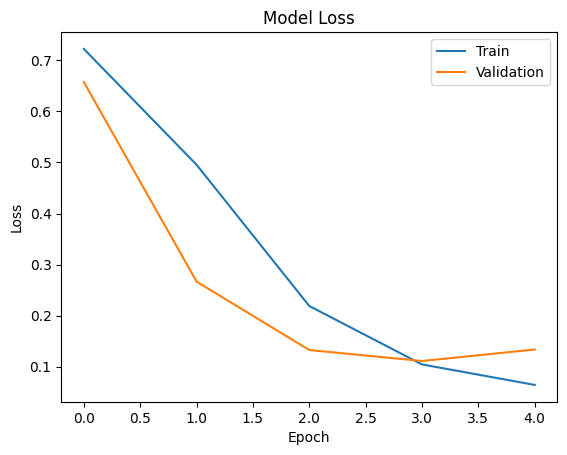

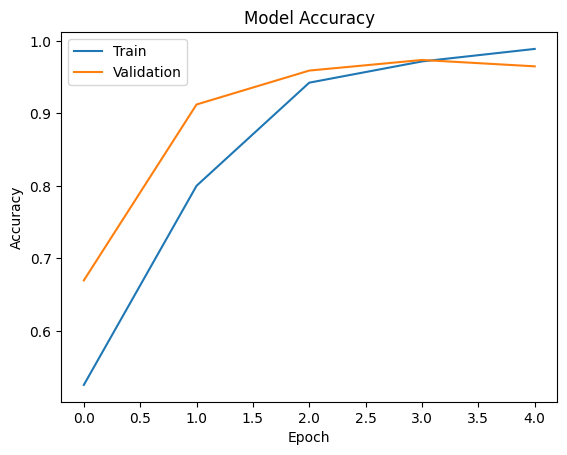

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       173
           1       0.82      0.71      0.77       112

    accuracy                           0.83       285
   macro avg       0.83      0.81      0.81       285
weighted avg       0.83      0.83      0.83       285

[[156  17]
 [ 32  80]]


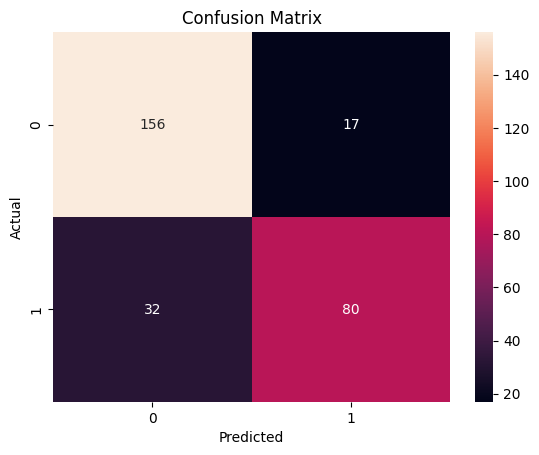

In [ ]:
y_pred = model.predict(X_test_pad)

y_pred_label = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_label))

cm = confusion_matrix(y_test, y_pred_label)
print(cm)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [ ]:
import re
from bs4 import BeautifulSoup

slang_dict = {
    "gk": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "nggak": "tidak",
    "tdk": "tidak",
    "bgt": "banget",
    "bngt": "banget",
    "bnr": "benar",
    "sy": "saya",
    "gw": "saya",
    "gue": "saya",
    "dr": "dari",
    "mntap": "mantap",
    "mantul": "mantap",
    "yg": "yang",
    "utk": "untuk",
    "jd": "jadi",
    "jg": "juga",
    "jln": "jalan",
    "krn": "karena",
    "dgn": "dengan",
    "blm": "belum",
    "sdh": "sudah",
    "msh": "masih",
    "aja": "saja",
    "emang": "memang",
    "trs": "terus",
    "dpt": "dapat",
    "sm": "sama",
    "kmrn": "kemarin",
    "tp": "tapi",
    "klo": "kalau",
    "kl": "kalau",
    "udh": "sudah",
    "udah": "sudah",
    "bs": "bisa",
    "byk": "banyak",
    "lg": "lagi",
    "lbh": "lebih",
}

def clean_text(text):
    text = str(text)

    text = text.lower()

    text = BeautifulSoup(text, "html.parser").get_text()

    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    units = r"(?:km|meter|menit|jam|rb|ribu|kg)"
    text = re.sub(r"(\d[\d\-\.]*\s*" + units + r")", r" \1 ", text)
    text = re.sub(r"\b\d+\b", " ", text)

    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [slang_dict.get(word, word) for word in tokens]

    text = " ".join(tokens)
    return text if len(text.split()) >= 2 else None

def predict_accessibility(text):
    text_clean = clean_text(text)
    if text_clean is None:
        return {"error": "Teks terlalu pendek setelah preprocessing"}

    sequence = tokenizer.texts_to_sequences([text_clean])
    padded = pad_sequences(sequence, maxlen=128, padding='post')

    prediction = model.predict(padded, verbose=0)[0]
    predicted_class = int(np.argmax(prediction))
    confidence = float(prediction[predicted_class])

    label = "Ramah Disabilitas" if predicted_class == 1 else "Akses Terbatas"

    return {
        "predicted_class": predicted_class,
        "confidence": confidence,
        "label": label
    }


test_text = "jalannya cukup rata dan bisa dilewati kursi roda dengan nyaman"

result = predict_accessibility(test_text)
print(result)

{'predicted_class': 1, 'confidence': 0.9186069965362549, 'label': 'Ramah Disabilitas'}


In [ ]:
test_text_2 = "pemandangannya bagus banget tapi jalanannya curam"

result_2 = predict_accessibility(test_text_2)
print(result_2)

{'predicted_class': 0, 'confidence': 0.985312283039093, 'label': 'Akses Terbatas'}


SAVE MODEL

In [ ]:
model.save("tripwell_bilstm.keras")

SAVE TOKENIZER

In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)